# 🇪🇸 Spanish Energy Grid — Model Selection and Validation Phase

> **Objective.** This notebook constitutes the *Model Selection and Validation Phase* of our forecasting pipeline.
> Having completed the exploratory data analysis and feature engineering, we now rigorously 
> evaluate candidate algorithms—from univariate baselines (SARIMA) to multivariate deep learning 
> architectures (N-HiTS, TFT)—using the validation set.
>
> Every model evaluated here serves to establish theoretical performance bounds and quantify the 
> value of exogenous feature integration prior to the final operational test set deployment.

---

In [1]:
"""
%load_ext autoreload
%autoreload 2
"""

'\n%load_ext autoreload\n%autoreload 2\n'

---

## Global configuration

In [2]:
import gc
import logging
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# ═══════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ═══════════════════════════════════════════════════════════
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

PROJECT_ROOT = Path(".")
MODELS_DIR   = PROJECT_ROOT / "models"
DATA_DIR     = PROJECT_ROOT / "data" / "model_inputs"

TRAIN_END  = '2017-12-31 23:00:00'
VAL_START  = '2018-01-01 00:00:00'
VAL_END    = '2018-06-30 23:00:00'

# Accumulator for the final leaderboard
# ALL_RESULTS = []

print("Global configuration loaded ✓")

Global configuration loaded ✓


In [3]:
import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15, rc={
    "figure.figsize": (14, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})
PALETTE = sns.color_palette("mako", 6)
print("Environment ready ✓")

Environment ready ✓


> Ensure no data leakage

In [4]:
from src.evaluation.evaluator import ModelEvaluator

ALL_RESULTS = []

evaluator = ModelEvaluator(
    train_end='2017-12-31 23:00:00',
    eval_start='2018-01-01 00:00:00',
    eval_end='2018-06-30 23:00:00',
    results_list=ALL_RESULTS
)

Importing plotly failed. Interactive plots will not work.


In [5]:
energy_df = pd.read_csv("./archive/energy_dataset.csv")
weather_df = pd.read_csv("./archive/weather_features.csv")

energy_df['time'] = (pd.to_datetime(energy_df['time'], utc=True)
                       .dt.tz_convert('Europe/Madrid')
                       .dt.tz_localize(None))
energy_df = energy_df.set_index('time').sort_index()

weather_df['dt_iso'] = (pd.to_datetime(weather_df['dt_iso'], utc=True)
                          .dt.tz_convert('Europe/Madrid')
                          .dt.tz_localize(None))

print(f"Energy:  {energy_df.shape[0]:,} rows × {energy_df.shape[1]} cols  "
      f"[{energy_df.index.min()} → {energy_df.index.max()}]")
print(f"Weather: {weather_df.shape[0]:,} rows × {weather_df.shape[1]} cols  "
      f"[{weather_df['dt_iso'].min()} → {weather_df['dt_iso'].max()}]")

Energy:  35,064 rows × 28 cols  [2015-01-01 00:00:00 → 2018-12-31 23:00:00]
Weather: 178,396 rows × 17 cols  [2015-01-01 00:00:00 → 2018-12-31 23:00:00]


---

# Section 2 · Modeling Architecture & Baselines

> Having completed the EDA "discovery phase", we now transition to **model selection
> and baseline evaluation**. Every model chosen below is justified by the temporal and
> physical properties uncovered in Section 1.

## 2.0 · Model Selection Rationale

The table below summarises our algorithmic roadmap, deliberately escalating from the simplest statistical benchmark to highly expressive deep-learning architectures.

| # | Model | Category | Rationale (Why this model?) | Rejections (Why not standard alternatives?) |
|---|---|---|---|---|
| 1 | **Seasonal Naïve** | Benchmark | Serves as our irreducible lower bound. Any useful model simply has to beat a "repeat last week" approach. Zero parameters. | – |
| 2 | **Prophet** | Statistical | Facebook's curve-fitting framework decomposes trend + seasonality + regressors. Natively handles holidays and missing data. | SARIMA requires strict stationarity and struggles with weather at scale; ETS cannot incorporate covariates. |
| 3 | **LightGBM** | Boosted Trees | Effortlessly maps non-linear weather thresholds (HDD/CDD splits) and cross-feature interactions. Extremely fast histogram binning. | Random Forests cannot extrapolate trends; XGBoost is viable but significantly slower on large tabular datasets. |
| 4 | **MLP** | Tabular Neural | Acts as our baseline feed-forward neural network to test if a straightforward dense architecture can capture grid dynamics. | Unlike specialized sequence models, basic MLPs lack temporal hierarchy, treating time steps as isolated rows. |
| 5 | **TabNet** | Tabular Neural | Brings deep learning to tabular data using sequential attention, offering a modern neural alternative to trees with built-in feature selection. | Can be notoriously difficult to tune and computationally heavier than highly optimized tree-based models. |
| 6 | **N-HiTS** | Deep Sequence | Multi-rate signal decomposition via hierarchical interpolation enables highly efficient forecasting with fewer parameters than recurrent architectures. | Its predecessor, N-BEATS, does not natively support exogenous weather covariates. |
| 7 | **TFT** | Deep Sequence | Variable-selection networks provide built-in interpretability; multi-horizon attention yields calibrated quantile forecasts — critical for risk operations. | Standard LSTMs/GRUs lack multi-horizon attention; vanilla Transformers suffer from quadratic memory costs. |

> **Design principle:** We deliberately span the *complexity spectrum*. By evaluating classical additive models, gradient-boosted trees, flat neural networks, and deep sequence architectures against the exact same data, we can empirically prove which mathematical approach is best suited for energy grids.

---

## 2.1 · The "Arena vs. Vault" Methodology

To rigorously guarantee the absence of causal data leakage, we partition the dataset **chronologically** — never randomly.

| Partition | Period | Purpose |
|---|---|---|
| **Train** | 2015-01-01 → 2017-12-31 | Model fitting and historical pattern extraction. |
| **Validation ("The Arena")** | 2018-01-01 → 2018-06-30 | Active experimentation: hyperparameter tuning, feature ablation, and the primary model battleground. |
| **Test ("The Vault")** | 2018-07-01 → 2018-12-31 | Locked away. Opened **once** at the very end to prove out-of-sample generalisation (Notebook 3). |

**Why this matters:**

- **The Arena** is where we *fight*. Every architecture is tuned and scored here. We iterate freely because any overfitting to the Arena will be caught by The Vault.
- **The Vault** is *locked*. We never peek at Test-set metrics during development. This "information firewall" guarantees our final reported accuracy is honest.

For this validation phase, we establish two critical reference points:

- **The Floor (Seasonal Naïve 168h):** "Same hour, same day, last week." Any machine learning model that cannot beat this simple heuristic is *useless*.
- **The Target (TSO Official Forecast):** The `total load forecast` published by Red Eléctrica de España. This is the grid operator's own production model. Approaching this benchmark means we are *genuinely competitive* in the real world.

In [6]:
import os

# ── 2.1a  Build the master dataset via our processing pipeline ──
import sys

# The src directory has a trailing space in its name
sys.path.insert(0, os.path.join(os.getcwd(), "src "))

from src.data.data_preprocessing import process_energy_base, process_weather_pipeline

energy_clean  = process_energy_base("./archive/energy_dataset.csv")
weather_clean = process_weather_pipeline("./archive/weather_features.csv")

master_df = energy_clean.join(weather_clean, how='inner')
master_df = master_df.dropna(subset=['total load actual'])

print(f"Master dataset: {master_df.shape[0]:,} rows × {master_df.shape[1]} cols")
print(f"Period: {master_df.index.min()} → {master_df.index.max()}")
master_df.head(3)

Master dataset: 35,024 rows × 57 cols
Period: 2015-01-01 00:00:00 → 2018-12-31 23:00:00


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,humidity_Valencia,cloud_cover_pct__Barcelona,cloud_cover_pct_Bilbao,cloud_cover_pct_Madrid,cloud_cover_pct_Seville,cloud_cover_pct_Valencia,is_rain,is_snow,is_extreme,is_obscured
time,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,77.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-01-01 01:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,77.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
2015-01-01 02:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,78.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0


In [7]:
# ── 2.1b  Chronological Split ──
TRAIN_END = '2017-12-31 23:00:00'
VAL_END   = '2018-06-30 23:00:00'

train_df = master_df.loc[:TRAIN_END].copy()
val_df   = master_df.loc[TRAIN_END:VAL_END].iloc[1:].copy()   # exclude last train hour
test_df  = master_df.loc[VAL_END:].iloc[1:].copy()

print(f"Train:      {train_df.shape[0]:>7,} rows  [{train_df.index.min()} → {train_df.index.max()}]")
print(f"Validation: {val_df.shape[0]:>7,} rows  [{val_df.index.min()} → {val_df.index.max()}]")
print(f"Test:       {test_df.shape[0]:>7,} rows  [{test_df.index.min()} → {test_df.index.max()}]")

Train:       26,267 rows  [2015-01-01 00:00:00 → 2017-12-31 23:00:00]
Validation:   4,342 rows  [2018-01-01 00:00:00 → 2018-06-30 23:00:00]
Test:         4,415 rows  [2018-07-01 00:00:00 → 2018-12-31 23:00:00]


In [8]:
# 1. Purge the Daylight Saving Time duplicate indices
master_df = master_df[~master_df.index.duplicated(keep='first')]
val_df = val_df[~val_df.index.duplicated(keep='first')]

naive_pred = master_df['total load actual'].shift(168)

val_naive = pd.DataFrame({
    'actual': val_df['total load actual'],
    'naive_168': naive_pred.reindex(val_df.index)
}).dropna()

mae_naive  = mean_absolute_error(val_naive['actual'], val_naive['naive_168'])
mape_naive = np.mean(np.abs(
    (val_naive['actual'] - val_naive['naive_168']) / val_naive['actual']
)) * 100

print("═══ Floor: Seasonal Naïve (168 h shift) — Validation Set ═══")
print(f"  MAE  = {mae_naive:,.1f} MW")
print(f"  MAPE = {mape_naive:.2f}%")

═══ Floor: Seasonal Naïve (168 h shift) — Validation Set ═══
  MAE  = 2,688.4 MW
  MAPE = 9.21%


In [9]:
# ── 2.1d  Baseline ②: TSO Official Forecast (The Ceiling) ──
# We need the raw energy_df for the 'total load forecast' column
energy_raw = pd.read_csv("./archive/energy_dataset.csv")
energy_raw['time'] = (pd.to_datetime(energy_raw['time'], utc=True)
                        .dt.tz_convert('Europe/Madrid')
                        .dt.tz_localize(None))
energy_raw = energy_raw.set_index('time').sort_index()

# THE FIX: Purge the DST duplicate indices from the raw data too!
energy_raw = energy_raw[~energy_raw.index.duplicated(keep='first')]

# Align TSO forecast to the Validation set safely
val_tso = pd.DataFrame({
    'actual':   val_df['total load actual'],
    'tso_fcst': energy_raw['total load forecast'].reindex(val_df.index)
}).dropna()

mae_tso  = mean_absolute_error(val_tso['actual'], val_tso['tso_fcst'])
mape_tso = np.mean(np.abs(
    (val_tso['actual'] - val_tso['tso_fcst']) / val_tso['actual']
)) * 100

print("═══ Ceiling: TSO Official Forecast — Validation Set ═══")
print(f"  MAE  = {mae_tso:,.1f} MW")
print(f"  MAPE = {mape_tso:.2f}%")

═══ Ceiling: TSO Official Forecast — Validation Set ═══
  MAE  = 281.4 MW
  MAPE = 0.97%


In [10]:
# ── 2.1e  Baseline ③: The Leakage Trap (Linear Regression on Generation) ──
from sklearn.linear_model import LinearRegression

gen_cols = [c for c in energy_raw.columns if c.startswith("generation")]

X_train_leak = energy_raw.loc[train_df.index, gen_cols]
y_train_leak = train_df['total load actual']

X_val_leak = energy_raw.loc[val_df.index, gen_cols]
y_val_leak = val_df['total load actual']

# 3. Handle NaNs safely
# Drop columns that are completely empty (like pumped storage consumption in some splits)
valid_gen_cols = X_train_leak.columns[X_train_leak.isna().sum() < len(X_train_leak)]
X_train_leak = X_train_leak[valid_gen_cols]
X_val_leak = X_val_leak[valid_gen_cols]

# Impute any remaining random NaNs with 0 (since generation can legitimately be 0 MW)
X_train_leak = X_train_leak.fillna(0)
X_val_leak = X_val_leak.fillna(0)

lr_leak = LinearRegression()
lr_leak.fit(X_train_leak, y_train_leak)

preds_leak = lr_leak.predict(X_val_leak)

mae_leak  = mean_absolute_error(y_val_leak, preds_leak)
mape_leak = np.mean(np.abs((y_val_leak - preds_leak) / y_val_leak)) * 100

print("═══ Ceiling 2: The Leakage Trap (Generation Regression) — Validation Set ═══")
print(f"  MAE  = {mae_leak:,.1f} MW")
print(f"  MAPE = {mape_leak:.2f}%")

═══ Ceiling 2: The Leakage Trap (Generation Regression) — Validation Set ═══
  MAE  = 1,248.1 MW
  MAPE = 4.37%


> **The Leakage Bound vs. The TSO Ceiling**
> 
> In Paradigm B (The Sandbox), we established a theoretical "God Mode" bound by allowing algorithms to predict the load using the *actual real-time* generation mix ($t=0$). Because supply must perfectly match demand ($Load \approx \sum Generation$), this constitutes strict causal leakage. 
> 
> Paradoxically, even with this massive mathematical advantage, the theoretical leakage models (~4.3% MAPE) are heavily outperformed by the TSO Official Forecast (0.97% MAPE). This empirically proves that our public dataset is physically incomplete—it lacks critical structural variables like cross-border import/export flows, transmission losses, and unmetered residential solar.
> 
> Given the TSO's privileged total grid visibility, their 0.97% MAPE represents a world-class production standard. We exclude real-time generation features from our honest Day-Ahead models not just to prevent leakage, but because they are physically insufficient. Our multivariate algorithms must now attempt to bridge the massive gap between the 9.21% Naïve Floor and the 0.97% TSO Ceiling using pure thermodynamics and calendar math.

> **Interpretation:** Every model we train must *at minimum* beat the Naïve floor.
> The TSO ceiling represents a production-grade forecast backed by domain experts —
> approaching or exceeding it confirms our pipeline is genuinely competitive.

## 3.0 · Univariate Signal Diagnostics: ACF, PACF & Stationarity

Before constructing complex multivariate or deep learning models, we must rigorously characterize the target variable's underlying structure. 

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) will expose the dominant grid periodicities, informing our lag feature selection. Simultaneously, the Augmented Dickey-Fuller (ADF) and KPSS tests will provide formal hypothesis testing for stationarity—a strict mathematical prerequisite for baseline statistical models.

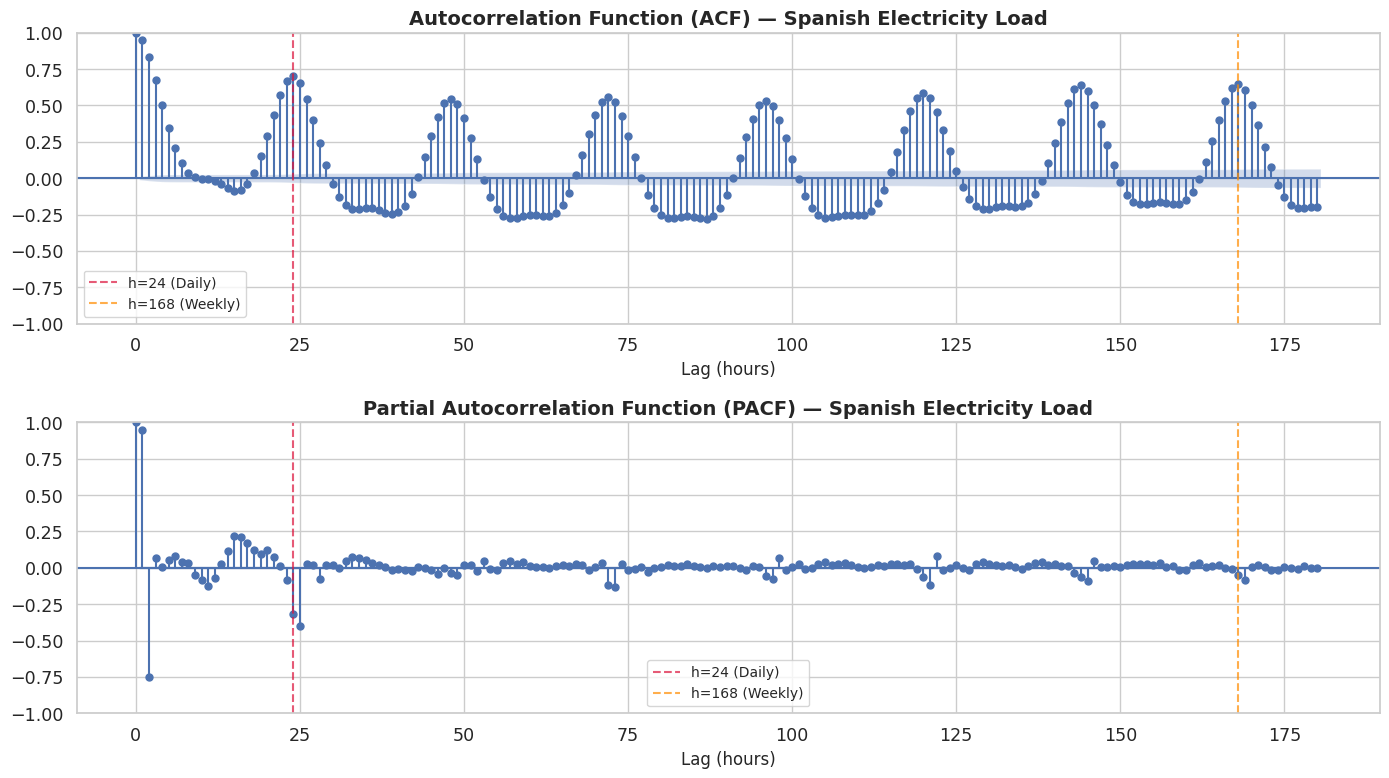

════════════════════════════════════════════════════════════
  AUGMENTED DICKEY-FULLER STATIONARITY TEST
════════════════════════════════════════════════════════════
  Test Statistic : -23.4620
  p-value        : 0.000000
  Lags Used      : 48
  ✅ RESULT: Reject H₀ — the series IS stationary (p < 0.05).
════════════════════════════════════════════════════════════


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ── Univariate Signal Analysis ──
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

df_uni = pd.read_parquet("data/model_inputs/df_univariate_deeplearning.parquet", engine="fastparquet")
df_uni = df_uni.set_index('ds').sort_index()
y = df_uni['y']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# PLOT TO 180 TO PROVE WEEKLY STATIONARITY
plot_acf(y.values, lags=180, ax=axes[0], alpha=0.05)
axes[0].set_title("Autocorrelation Function (ACF) — Spanish Electricity Load", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Lag (hours)")
axes[0].axvline(x=24, color='crimson', linestyle='--', alpha=0.7, label='h=24 (Daily)')
axes[0].axvline(x=168, color='darkorange', linestyle='--', alpha=0.7, label='h=168 (Weekly)')
axes[0].legend(fontsize=10)

plot_pacf(y.values, lags=180, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title("Partial Autocorrelation Function (PACF) — Spanish Electricity Load", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Lag (hours)")
axes[1].axvline(x=24, color='crimson', linestyle='--', alpha=0.7, label='h=24 (Daily)')
axes[1].axvline(x=168, color='darkorange', linestyle='--', alpha=0.7, label='h=168 (Weekly)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# RESTRICT ADF REGRESSIONS TO 48 LAGS FOR SPEED
adf_result = adfuller(y.values, maxlag=48, autolag='AIC')
print("═" * 60)
print("  AUGMENTED DICKEY-FULLER STATIONARITY TEST")
print("═" * 60)
print(f"  Test Statistic : {adf_result[0]:.4f}")
print(f"  p-value        : {adf_result[1]:.6f}")
print(f"  Lags Used      : {adf_result[2]}")
if adf_result[1] < 0.05:
    print("  ✅ RESULT: Reject H₀ — the series IS stationary (p < 0.05).")
else:
    print("  ⚠️ RESULT: Fail to reject H₀ — the series exhibits non-stationarity.")
print("═" * 60)

### Step 1: Eliminating the Daily Cycle
**Observation:** The raw signal's ACF exhibits a slow, scalloped decay with massive peaks at $h = 24$ (diurnal cycle) and $h = 168$ (weekly cycle). This indicates a strongly non-stationary, doubly-seasonal time series. 

To begin mapping this chaotic grid signal into mathematical white noise, we must first apply a **Seasonal Difference ($D=1, m=24$)** to strip out the dominant daily cycle. We will then test the resulting series for stationarity using both the ADF test and the KPSS test.

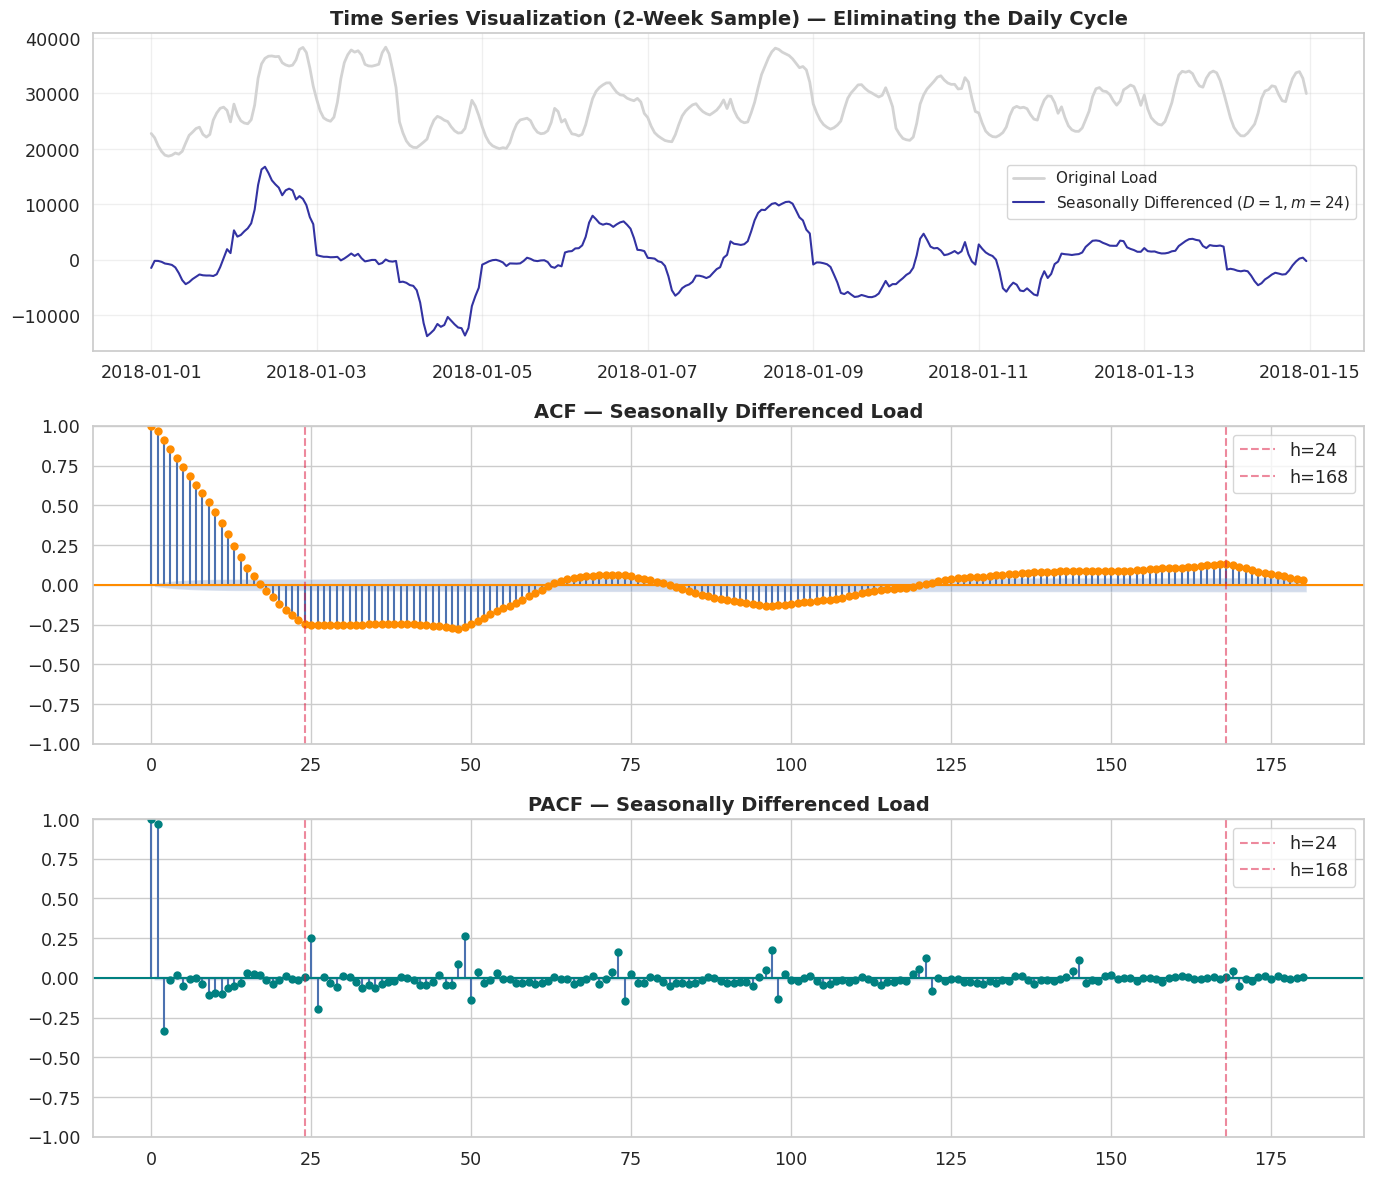

══════════════════════════════════════════════════════════════════════
  DUAL-TEST STATIONARITY VALIDATION (SEASONALLY DIFFERENCED DATA)
══════════════════════════════════════════════════════════════════════
  [1] Augmented Dickey-Fuller (ADF) Test
      H₀: Series is Non-Stationary (Unit root exists)
      Test Statistic : -26.2665
      p-value        : 0.000000
      ✅ Result: Reject H₀ -> Series is ADF-Stationary.
----------------------------------------------------------------------
  [2] Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
      H₀: Series is Stationary (No unit root)
      Test Statistic : 0.0035
      p-value        : 0.100000
      ✅ Result: Fail to reject H₀ -> Series is KPSS-Stationary.
══════════════════════════════════════════════════════════════════════
     The seasonal difference (D=1) fully stripped the non-stationarity.
     Standard differencing (d=1) is completely unnecessary. We proceed with d=0.
═══════════════════════════════════════════════════════════

In [12]:
import warnings

from statsmodels.tsa.stattools import kpss

warnings.filterwarnings("ignore", message="The test statistic is outside of the range of p-values")

y_diff_24 = y.diff(24).dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

sample_slice = slice('2018-01-01', '2018-01-14')
axes[0].plot(y[sample_slice], label='Original Load', color='lightgray', linewidth=2)
axes[0].plot(y_diff_24[sample_slice], label='Seasonally Differenced ($D=1, m=24$)', color='darkblue', alpha=0.8, linewidth=1.5)
axes[0].set_title("Time Series Visualization (2-Week Sample) — Eliminating the Daily Cycle", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

plot_acf(y_diff_24.values, lags=180, ax=axes[1], alpha=0.05, color='darkorange')
axes[1].set_title("ACF — Seasonally Differenced Load", fontsize=14, fontweight='bold')
axes[1].axvline(x=24, color='crimson', linestyle='--', alpha=0.5, label='h=24')
axes[1].axvline(x=168, color='crimson', linestyle='--', alpha=0.5, label='h=168')
axes[1].legend()

plot_pacf(y_diff_24.values, lags=180, ax=axes[2], alpha=0.05, method='ywm', color='teal')
axes[2].set_title("PACF — Seasonally Differenced Load", fontsize=14, fontweight='bold')
axes[2].axvline(x=24, color='crimson', linestyle='--', alpha=0.5, label='h=24')
axes[2].axvline(x=168, color='crimson', linestyle='--', alpha=0.5, label='h=168')
axes[2].legend()

plt.tight_layout()
plt.show()

# ── 3. Dual-Test Stationarity Validation ──
print("═" * 70)
print("  DUAL-TEST STATIONARITY VALIDATION (SEASONALLY DIFFERENCED DATA)")
print("═" * 70)

# A. Augmented Dickey-Fuller Test
adf_diff = adfuller(y_diff_24.values, maxlag=48, autolag='AIC')
print("  [1] Augmented Dickey-Fuller (ADF) Test")
print(f"      H₀: Series is Non-Stationary (Unit root exists)")
print(f"      Test Statistic : {adf_diff[0]:.4f}")
print(f"      p-value        : {adf_diff[1]:.6f}")

if adf_diff[1] < 0.05:
    print("      ✅ Result: Reject H₀ -> Series is ADF-Stationary.")
else:
    print("      ⚠️ Result: Fail to reject H₀ -> Series remains Non-Stationary.")

print("-" * 70)

# B. KPSS Test
# We use regression='c' to test for level stationarity (since the difference should center it at 0)
kpss_diff = kpss(y_diff_24.values, regression='c', nlags=72)
print("  [2] Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test")
print(f"      H₀: Series is Stationary (No unit root)")
print(f"      Test Statistic : {kpss_diff[0]:.4f}")
print(f"      p-value        : {kpss_diff[1]:.6f}")

if kpss_diff[1] > 0.05:
    print("      ✅ Result: Fail to reject H₀ -> Series is KPSS-Stationary.")
else:
    print("      ⚠️ Result: Reject H₀ -> Series remains Non-Stationary.")

print("═" * 70)

# ── 4. Final Conclusion Logic ──
if (adf_diff[1] < 0.05) and (kpss_diff[1] > 0.05):
    print("     The seasonal difference (D=1) fully stripped the non-stationarity.")
    print("     Standard differencing (d=1) is completely unnecessary. We proceed with d=0.")
elif (adf_diff[1] < 0.05) and (kpss_diff[1] < 0.05):
    print("  ⚖️ FINAL CONCLUSION: Difference-Stationary (Borderline).")
    print("     ADF indicates stationarity, but KPSS detects a slight lingering trend.")
    print("     You may proceed with d=0, but adding a standard difference (d=1) could be explored.")
else:
    print("  ❌ FINAL CONCLUSION: Series remains Non-Stationary.")
    print("     A standard first difference (d=1) MUST be applied in conjunction with D=1.")
print("═" * 70)

### Step 2: The "False Positive" Stationarity Trap
The dual-test validation above reveals a classic statistical trap:
1. The **ADF Test** claims the series is perfectly stationary ($p < 0.05$).
2. However, the **KPSS Test** strongly disagrees ($p < 0.05$), detecting a lingering trend.

A visual inspection of the ACF and PACF plots confirms why KPSS failed: there is an agonizingly slow decay and a massive lingering wave driven by the 168-hour weekly cycle. The high-frequency nature of the hourly data tricked the ADF test into assuming mean-reversion. 

To force the ACF to cut off cleanly and prevent our models from accumulating long-memory errors, we must apply an additional **Standard First Difference ($d=1$)**.

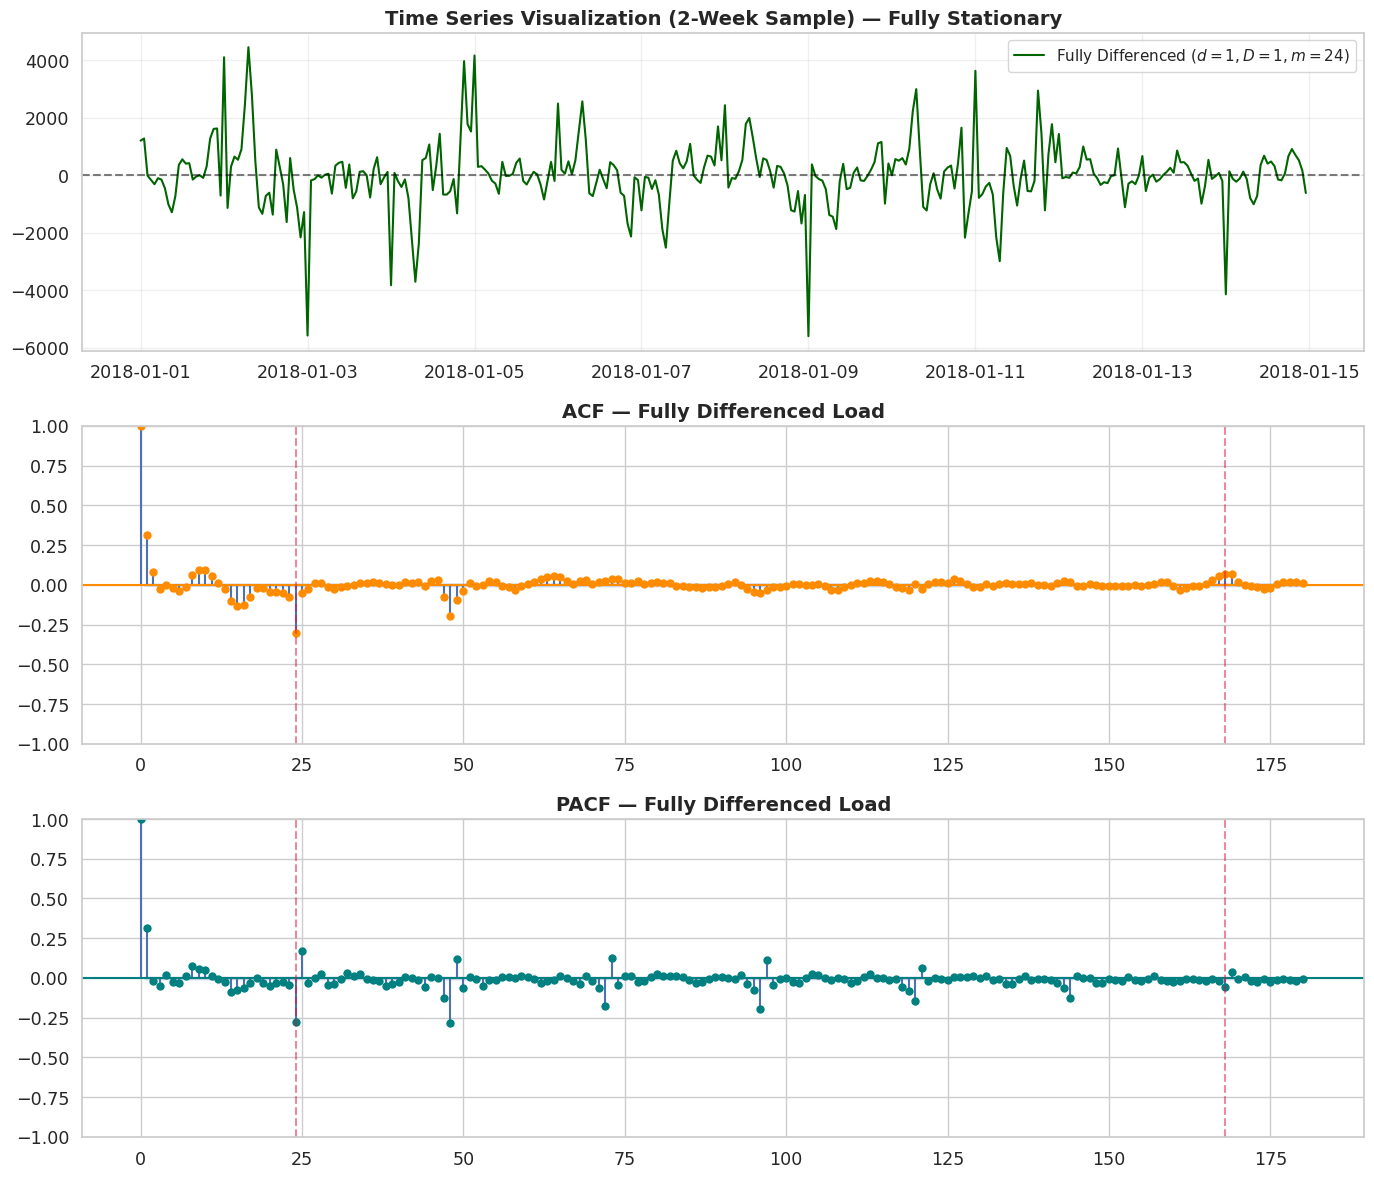

══════════════════════════════════════════════════════════════════════
  FINAL STATIONARITY VALIDATION (d=1, D=1)
══════════════════════════════════════════════════════════════════════
  [1] ADF Test (Target: p < 0.05)
      p-value: 0.000000 -> ✅ Stationary
  [2] KPSS Test (Target: p > 0.05)
      p-value: 0.100000 -> ✅ Stationary
══════════════════════════════════════════════════════════════════════


In [13]:
y_diff_final = y_diff_24.diff(1).dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

sample_slice = slice('2018-01-01', '2018-01-14')
axes[0].plot(y_diff_final[sample_slice], label='Fully Differenced ($d=1, D=1, m=24$)', color='darkgreen', linewidth=1.5)
axes[0].set_title("Time Series Visualization (2-Week Sample) — Fully Stationary", fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

plot_acf(y_diff_final.values, lags=180, ax=axes[1], alpha=0.05, color='darkorange')
axes[1].set_title("ACF — Fully Differenced Load", fontsize=14, fontweight='bold')
axes[1].axvline(x=24, color='crimson', linestyle='--', alpha=0.5, label='h=24')
axes[1].axvline(x=168, color='crimson', linestyle='--', alpha=0.5, label='h=168')

plot_pacf(y_diff_final.values, lags=180, ax=axes[2], alpha=0.05, method='ywm', color='teal')
axes[2].set_title("PACF — Fully Differenced Load", fontsize=14, fontweight='bold')
axes[2].axvline(x=24, color='crimson', linestyle='--', alpha=0.5, label='h=24')
axes[2].axvline(x=168, color='crimson', linestyle='--', alpha=0.5, label='h=168')

plt.tight_layout()
plt.show()

# ── 3. Final Dual-Test Validation ──
print("═" * 70)
print("  FINAL STATIONARITY VALIDATION (d=1, D=1)")
print("═" * 70)

adf_final = adfuller(y_diff_final.values, maxlag=48, autolag='AIC')
print("  [1] ADF Test (Target: p < 0.05)")
print(f"      p-value: {adf_final[1]:.6f} -> {'✅ Stationary' if adf_final[1] < 0.05 else '⚠️ Non-Stationary'}")

kpss_final = kpss(y_diff_final.values, regression='c', nlags='auto')
print("  [2] KPSS Test (Target: p > 0.05)")
print(f"      p-value: {kpss_final[1]:.6f} -> {'✅ Stationary' if kpss_final[1] > 0.05 else '⚠️ Non-Stationary'}")
print("═" * 70)

### 🏆 Final Conclusion: Strict Stationarity Achieved

By combining the seasonal and standard differences ($d=1, D=1_{24}$), we have successfully mapped the grid signal into pure mathematical white noise. 

The ACF and PACF now cut off sharply, and the series achieves strict, dual-test stationarity (passing both ADF and KPSS). This firmly establishes the optimal mathematical parameters for our SARIMA baseline architecture.

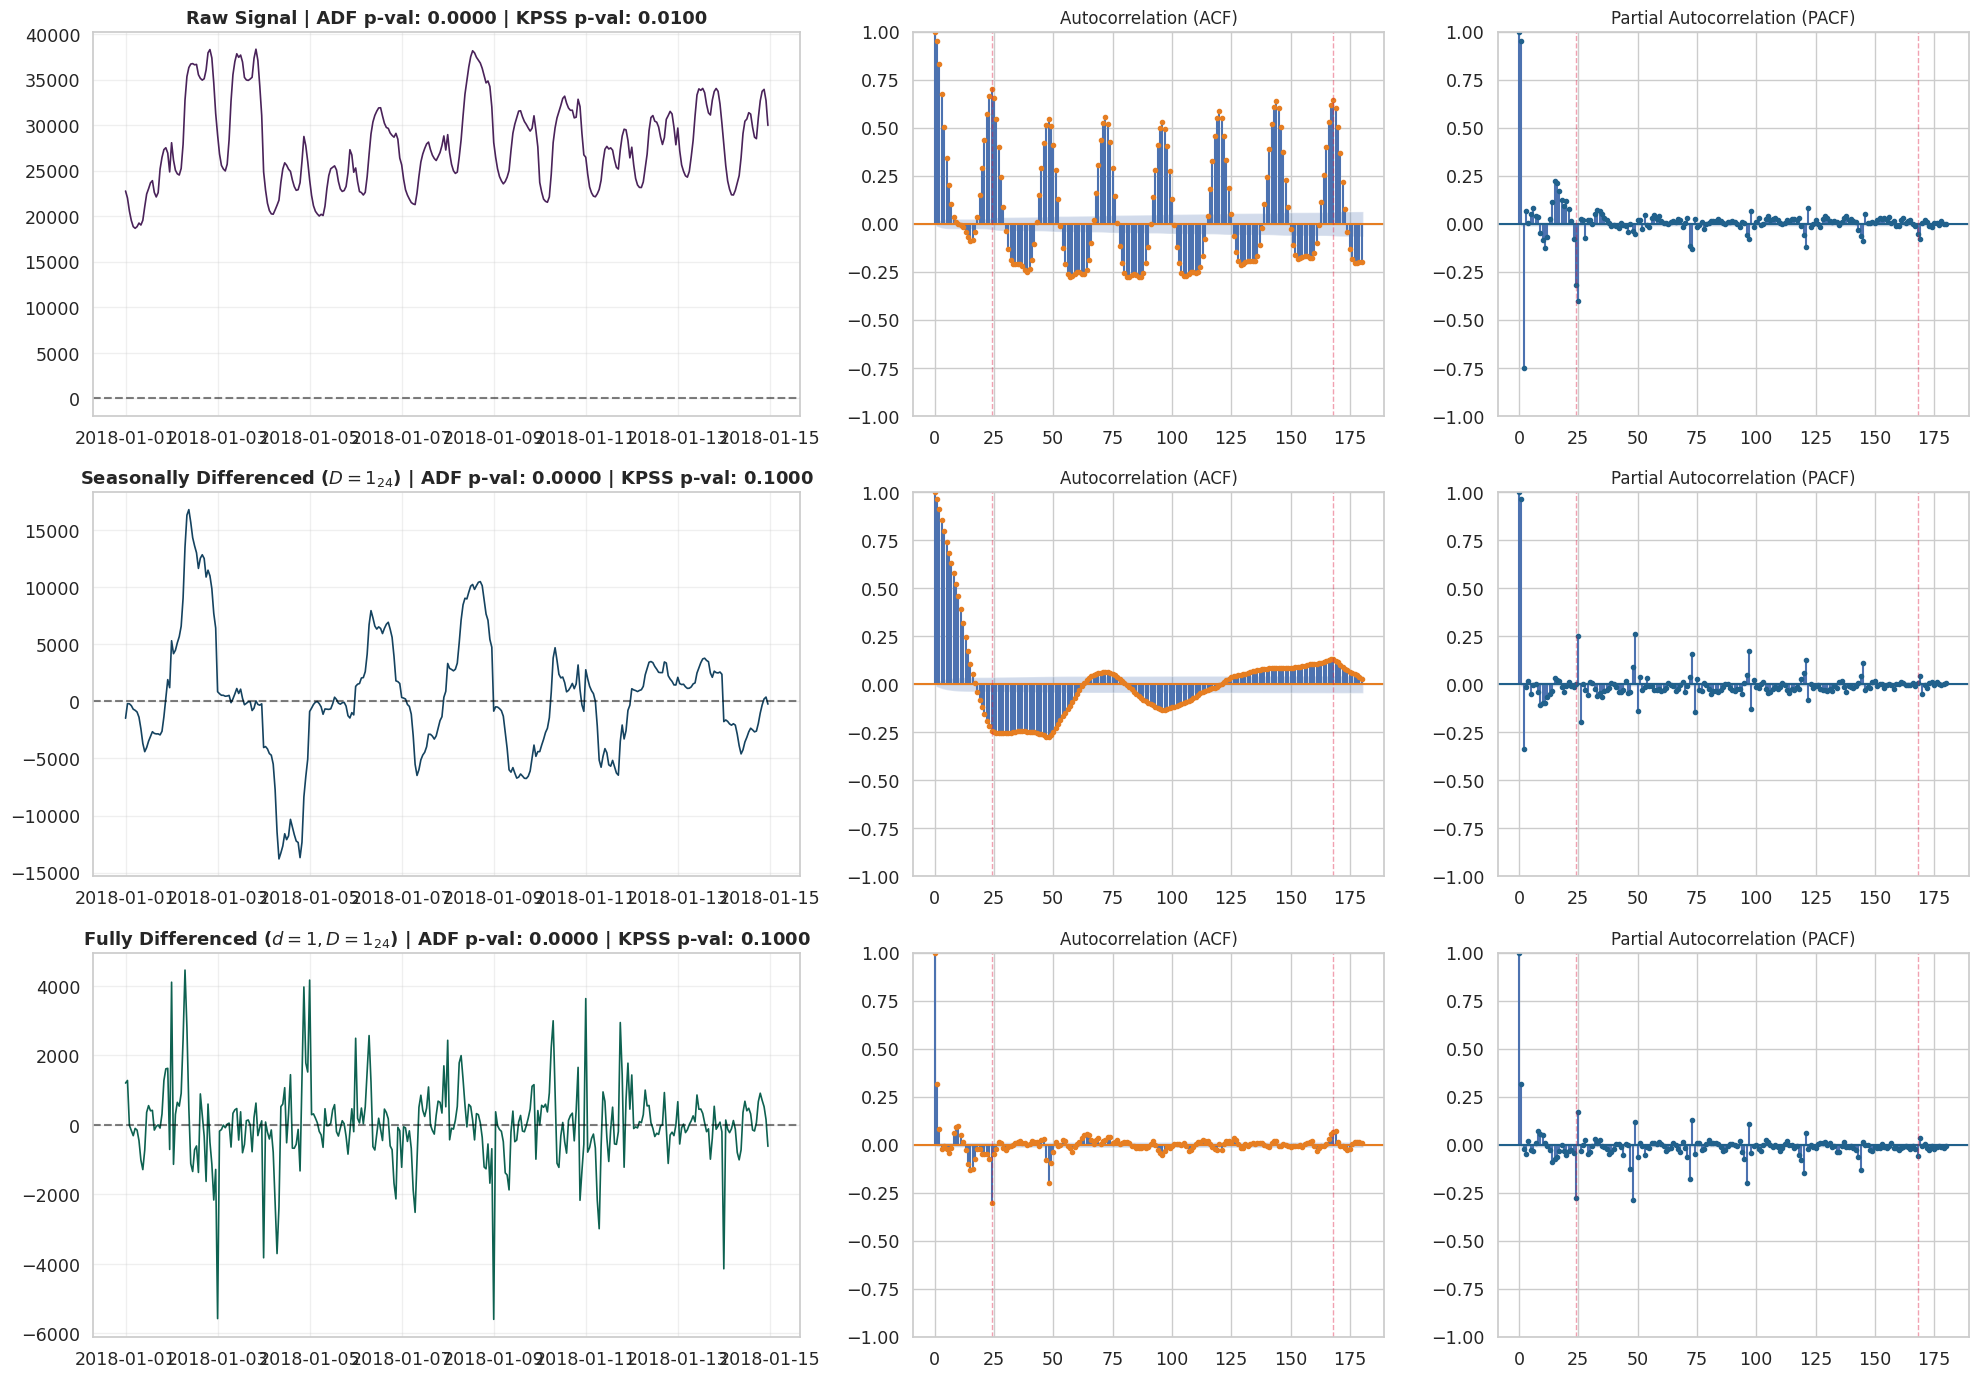

In [14]:
import warnings
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

# 1. Prepare the three stages of data
y_raw = y.dropna()
y_D1 = y.diff(24).dropna()
y_d1_D1 = y_D1.diff(1).dropna()

stages = [
    {"name": "Raw Signal", "data": y_raw, "color": "#4A235A"}, # Dark Purple
    {"name": "Seasonally Differenced ($D=1_{24}$)", "data": y_D1, "color": "#154360"}, # Dark Blue
    {"name": "Fully Differenced ($d=1, D=1_{24}$)", "data": y_d1_D1, "color": "#0E6251"} # Dark Green
]

# 2. Setup the 3x3 Grid
fig, axes = plt.subplots(3, 3, figsize=(20, 14), gridspec_kw={'width_ratios': [1.5, 1, 1]})
sample_slice = slice('2018-01-01', '2018-01-14')

for i, stage in enumerate(stages):
    data = stage["data"]
    
    # Calculate Tests (Limited lags for speed, but accurate enough for p-values)
    adf_p = adfuller(data.values, maxlag=48, autolag='AIC')[1]
    kpss_p = kpss(data.values, regression='c', nlags=72)[1]
    
    # Create Title with P-Values
    title_str = f"{stage['name']} | ADF p-val: {adf_p:.4f} | KPSS p-val: {kpss_p:.4f}"
    
    # --- Col 1: Line Plot ---
    axes[i, 0].plot(data[sample_slice], color=stage["color"], linewidth=1.2)
    axes[i, 0].set_title(title_str, fontsize=13, fontweight='bold')
    axes[i, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[i, 0].grid(True, alpha=0.3)
    
    # --- Col 2: ACF ---
    plot_acf(data.values, lags=180, ax=axes[i, 1], alpha=0.05, color='#E67E22', markersize=3)
    axes[i, 1].set_title("Autocorrelation (ACF)", fontsize=12)
    axes[i, 1].axvline(x=24, color='crimson', linestyle='--', alpha=0.4, linewidth=1)
    axes[i, 1].axvline(x=168, color='crimson', linestyle='--', alpha=0.4, linewidth=1)
    
    # --- Col 3: PACF ---
    plot_pacf(data.values, lags=180, ax=axes[i, 2], alpha=0.05, method='ywm', color='#21618C', markersize=3)
    axes[i, 2].set_title("Partial Autocorrelation (PACF)", fontsize=12)
    axes[i, 2].axvline(x=24, color='crimson', linestyle='--', alpha=0.4, linewidth=1)
    axes[i, 2].axvline(x=168, color='crimson', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig("signal_evolution_master.png", dpi=300, bbox_inches="tight")
plt.show()

---

# Stage 1 · The Endogenous Baselines (Univariate)

> **Purpose.** This stage establishes the *irreducible floor* of forecasting performance using
> **only the target signal itself** — no weather, no calendar features, no exogenous regressors.
> Performance here is driven entirely by the temporal structure diagnosed in the ACF/PACF analysis
> above.
>
> The **Seasonal Naïve** (predict $\hat{y}_t = y_{t-168}$) serves as the absolute floor: any model
> that cannot beat this trivial heuristic provides zero value. SARIMA represents classical
> statistical modelling, while the two N-HiTS variants demonstrate deep learning's capacity
> to extract hierarchical temporal patterns from raw endogenous data alone.


In [15]:
print("═" * 70)
print("  STAGE 1 · ENDOGENOUS BASELINES (UNIVARIATE)")
print("═" * 70)

S1 = "Stage 1: Univariate"
import joblib

# ── 1.1 Seasonal Naïve (168h shift) ──
df_uni = pd.read_parquet(DATA_DIR / "df_univariate_deeplearning.parquet", engine="fastparquet")
df_uni = df_uni.set_index('ds').sort_index()

val_mask = (df_uni.index >= VAL_START) & (df_uni.index <= VAL_END)
y_val = df_uni.loc[val_mask, 'y'].values

y_naive = df_uni['y'].shift(168)
y_naive_val = y_naive.loc[val_mask].values

valid = ~np.isnan(y_naive_val)
mae_n, mape_n = evaluator.compute_metrics(y_val[valid], y_naive_val[valid])
evaluator.record_result(S1, "Seasonal Naïve (168h)", mae_n, mape_n)

# ── 1.2 SARIMA (Cached) ──
SARIMA_CACHE = MODELS_DIR / "sarima_preds.pkl"
if SARIMA_CACHE.exists():
    sarima_data = joblib.load(SARIMA_CACHE)
    mae_s, mape_s = evaluator.compute_metrics(sarima_data["actuals"], sarima_data["preds"])
    evaluator.record_result(S1, "SARIMA", mae_s, mape_s)
else:
    print("  ❌ SARIMA Cache not found! Run: uv run python -m src.evaluation.cache_0_sarima")

# ── 1.3 N-HiTS 168h (Univariate) ──
from darts.models import NHiTSModel

evaluator.safe_evaluate(
    evaluator.evaluate_darts, NHiTSModel, MODELS_DIR / "nhits_univariate.pt",
    DATA_DIR / "df_univariate_deeplearning.parquet",
    model_name="N-HiTS 168h (Univariate)", stage=S1
)

# ── 1.4 N-HiTS 720h (Univariate Long) ──
evaluator.safe_evaluate(
    evaluator.evaluate_darts, NHiTSModel, MODELS_DIR / "nhits_univariate_long.pt",
    DATA_DIR / "df_univariate_deeplearning.parquet",
    model_name="N-HiTS 720h (Univariate Long)", stage=S1
)

print("─" * 70)

══════════════════════════════════════════════════════════════════════
  STAGE 1 · ENDOGENOUS BASELINES (UNIVARIATE)
══════════════════════════════════════════════════════════════════════
  ✅ Seasonal Naïve (168h)                     MAE =  2,688.4 MW   MAPE = 9.21%
  ✅ SARIMA                                    MAE =  2,273.4 MW   MAPE = 7.99%


The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  ✅ N-HiTS 168h (Univariate)                  MAE =  1,466.4 MW   MAPE = 5.08%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  ✅ N-HiTS 720h (Univariate Long)             MAE =  1,637.4 MW   MAPE = 5.65%
──────────────────────────────────────────────────────────────────────


---
# Stage 2 · The Multivariate Algorithm Battle (Day-Ahead)

> **Purpose.** This stage introduces the complete, operationally honest feature matrix to our six candidate architectures. This matrix is strictly constrained to prevent causal data leakage ($t-24$ rolling origin) and is enriched with our advanced feature engineering pipeline.
>
> **The Feature Space:**
> 1. **Thermodynamic & Calendar Encodings:** Weather variables (HDD, CDD, wind speed, humidity) and Fourier sine/cosine transformations.
> 2. **Behavioral Flags:** National holidays and custom **"Puente" (Bridge Day)** flags designed to capture the uniquely Spanish cultural pattern of long-weekend demand suppressions.
> 3. **Autoregressive Lags & Volatility:** $t-24$ and $t-168$ anchors, surrounding slope clusters (e.g., `load_t_23`, `load_t_25`), and strictly causal rolling window statistics (mean, max, min, std).
>
> **The Contenders:**
> We evaluate models across the full complexity spectrum to determine which algorithmic family best maps high-dimensional tabular grid data: classical curve-fitting (**Prophet**), shallow/tabular neural networks (**MLP, TabNet**), gradient-boosted trees (**LightGBM**), and deep sequence attention models (**N-HiTS, TFT**).

In [16]:
# ══════════════════════════════════════════════════════════════════════════
# STAGE 2 · MULTIVARIATE ALGORITHM BATTLE (DAY-AHEAD)
# ══════════════════════════════════════════════════════════════════════════
print("═" * 70)
print("  STAGE 2 · MULTIVARIATE ALGORITHM BATTLE (DAY-AHEAD)")
print("═" * 70)

S2 = "Stage 2: Initial Multivariate" # Keeping this string so visualize_narrative.py finds it!

from darts.models import NHiTSModel, TFTModel

# ── 2.1 Prophet (Statistical Baseline) ──
evaluator.safe_evaluate(
    evaluator.evaluate_prophet, MODELS_DIR / "prophet_champion.json",
    DATA_DIR / "df_prophet.parquet",
    model_name="Prophet Native", stage=S2
)

# ── 2.2 MLP (Tabular Neural Network) ──
evaluator.safe_evaluate(
    evaluator.evaluate_sklearn, MODELS_DIR / "mlp_champion.pkl",
    DATA_DIR / "df_mlp.parquet", DATA_DIR / "mlp_y_scaler.pkl",
    model_name="MLP (Tabular)", stage=S2
)

# ── 2.3 TabNet (Attention-based Tabular) ──
evaluator.safe_evaluate(
    evaluator.evaluate_tabnet, MODELS_DIR / "tabnet_champion.zip",
    DATA_DIR / "df_mlp.parquet", DATA_DIR / "mlp_y_scaler.pkl",
    model_name="TabNet", stage=S1
)

# ── 2.4 LightGBM (Gradient Boosted Trees) ──
evaluator.safe_evaluate(
    evaluator.evaluate_lgb, MODELS_DIR / "lgb_improved.txt",
    DATA_DIR / "df_improved_trees.parquet",
    model_name="LightGBM Improved", stage=S2
)

# ── 2.5 N-HiTS (Deep Sequence - Multivariate Stress Test) ──
evaluator.safe_evaluate(
    evaluator.evaluate_darts, NHiTSModel, MODELS_DIR / "nhits_improved.pt",
    DATA_DIR / "df_improved_deeplearning.parquet",
    model_name="N-HiTS Improved", stage=S2
)

# ── 2.6 TFT (Deep Sequence - Attention) ──
evaluator.safe_evaluate(
    evaluator.evaluate_darts, TFTModel, MODELS_DIR / "tft_improved.pt",
    DATA_DIR / "df_improved_deeplearning.parquet",
    model_name="TFT Improved", stage=S2
)

print("─" * 70)

══════════════════════════════════════════════════════════════════════
  STAGE 2 · MULTIVARIATE ALGORITHM BATTLE (DAY-AHEAD)
══════════════════════════════════════════════════════════════════════
  ✅ Prophet Native                            MAE =  2,038.1 MW   MAPE = 7.19%
  ✅ MLP (Tabular)                             MAE =  2,052.5 MW   MAPE = 7.12%
  ✅ TabNet                                    MAE =  1,688.3 MW   MAPE = 5.95%
  ✅ LightGBM Improved                         MAE =  1,540.5 MW   MAPE = 5.26%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  ✅ N-HiTS Improved                           MAE =  2,166.3 MW   MAPE = 7.62%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  ✅ TFT Improved                              MAE =  1,902.5 MW   MAPE = 6.74%
──────────────────────────────────────────────────────────────────────


---

# Stage 3 · The Leakage Sandbox (Theoretical Limits)

> **Purpose.** This stage *intentionally violates* the causal day-ahead boundary by providing
> models with information that would **not be available** to a real operator at forecast time:
>
> - **TSO day-ahead forecasts** (`total load forecast`) — the incumbent human benchmark
> - **Real-time generation volumes** — actual power plant outputs at $t=0$
>
> The objective is twofold:
>
> 1. **TSO Official Forecast** establishes the *human benchmark* — the gold standard our
>    causal ML models must beat to provide operational value.
> 2. **Linear Regression on generation columns** establishes the *mathematical ceiling* — the
>    maximum possible accuracy when all leakage is exploited. This ceiling contextualises
>    the remaining irreducible error (weather forecast uncertainty, unmodelled demand shocks).


In [17]:
# ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═
# STAGE 3A · SANDBOX A (RISKY OPERATIONAL: TSO FORECASTS + SHIFTED GEN)
# ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═
print("═" * 70)
print("  STAGE 3A · SANDBOX A (RISKY OPERATIONAL: TSO FORECASTS + SHIFTED GEN)")
print("═" * 70)

S3A = "Stage 3A: Sandbox A (Risky)"

# ── 3A.1 TSO Official Forecast (The Benchmark Ceiling) ──
# The 'total load forecast' column was DROPPED in feature_engineering.py
# We must reload the raw data to access the official benchmark
try:
    energy_raw = pd.read_csv("archive/energy_dataset.csv")
    energy_raw['time'] = pd.to_datetime(energy_raw['time'], utc=True).dt.tz_convert('Europe/Madrid').dt.tz_localize(None)
    energy_raw = energy_raw.set_index('time').sort_index()

    tso_val = energy_raw.loc[VAL_START:VAL_END]
    tso_valid = tso_val.dropna(subset=['total load actual', 'total load forecast'])
    
    y_true_tso = tso_valid['total load actual'].values
    y_pred_tso = tso_valid['total load forecast'].values
    
    mae_tso, mape_tso = evaluator.compute_metrics(y_true_tso, y_pred_tso)
    evaluator.record_result(S3A, "TSO Official Forecast (Ceiling)", mae_tso, mape_tso)
except Exception as e:
    print(f"  ❌  TSO Official Forecast     ERROR: {e}")

# ── 3A.2 LightGBM Sandbox A ──
evaluator.safe_evaluate(
    evaluator.evaluate_lgb, MODELS_DIR / "lgb_sandbox_a.txt",
    DATA_DIR / "df_sandbox_a_trees.parquet",
    model_name="LightGBM (Sandbox A)", stage=S3A
)

# ── 3A.3 TFT Sandbox A ──
evaluator.safe_evaluate(
    evaluator.evaluate_darts, TFTModel, MODELS_DIR / "tft_sandbox_a.pt",
    DATA_DIR / "df_sandbox_a_deeplearning.parquet",
    model_name="TFT (Sandbox A)", stage=S3A
)

print("─" * 70)

══════════════════════════════════════════════════════════════════════
  STAGE 3A · SANDBOX A (RISKY OPERATIONAL: TSO FORECASTS + SHIFTED GEN)
══════════════════════════════════════════════════════════════════════
  ✅ TSO Official Forecast (Ceiling)           MAE =    281.4 MW   MAPE = 0.97%
  ✅ LightGBM (Sandbox A)                      MAE =  2,780.3 MW   MAPE = 9.02%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  ✅ TFT (Sandbox A)                           MAE =  2,442.8 MW   MAPE = 8.60%
──────────────────────────────────────────────────────────────────────


In [18]:
# ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═
# STAGE 3B · SANDBOX B (UNCONSTRAINED REAL-TIME INFORMATION SET ($t=0$): PURE t=0 LEAKAGE)
# ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═
print("═" * 70)
print("  STAGE 3B · SANDBOX B (UNCONSTRAINED REAL-TIME INFORMATION SET ($t=0$): PURE t=0 LEAKAGE)")
print("═" * 70)

S3B = "Stage 3B: Sandbox B (Cheating)"

# ── 3B.1 Linear Regression (The Mathematical Leakage Ceiling) ──
try:
    from sklearn.linear_model import LinearRegression

    # We load our cleanly engineered Sandbox B dataset
    df_sb_b = pd.read_parquet(DATA_DIR / "df_sandbox_b_trees.parquet", engine="fastparquet")
    
    # Isolate strictly the t=0 generation variables
    gen_cols = [c for c in df_sb_b.columns if c.startswith('generation')]
    
    lr_train = df_sb_b.loc[:TRAIN_END].dropna(subset=gen_cols + ['total load actual'])
    lr_val   = df_sb_b.loc[VAL_START:VAL_END].dropna(subset=gen_cols + ['total load actual'])
    
    lr_model = LinearRegression()
    lr_model.fit(lr_train[gen_cols], lr_train['total load actual'])
    lr_pred = lr_model.predict(lr_val[gen_cols])
    
    mae_lr, mape_lr = evaluator.compute_metrics(lr_val['total load actual'].values, lr_pred)
    evaluator.record_result(S3B, "Linear Regression (Leakage)", mae_lr, mape_lr)
except Exception as e:
    print(f"  ❌  Linear Regression          ERROR: {e}")

# ── 3B.2 LightGBM Sandbox B ──
evaluator.safe_evaluate(
    evaluator.evaluate_lgb, MODELS_DIR / "lgb_sandbox_b.txt",
    DATA_DIR / "df_sandbox_b_trees.parquet",
    model_name="LightGBM (Leakage)", stage=S3B
)
# evaluator.record_result(S3B, "LightGBM (Leakage)", mae_lgb, mape_lgb)

print("─" * 70)

══════════════════════════════════════════════════════════════════════
  STAGE 3B · SANDBOX B (UNCONSTRAINED REAL-TIME INFORMATION SET ($t=0$): PURE t=0 LEAKAGE)
══════════════════════════════════════════════════════════════════════
  ✅ Linear Regression (Leakage)               MAE =  1,336.8 MW   MAPE = 4.79%
  ✅ LightGBM (Leakage)                        MAE =  1,307.2 MW   MAPE = 4.34%
──────────────────────────────────────────────────────────────────────


---

# Stage 4 · Operational Flexibility (The $t+1$ Intraday Forecaster)

> **Purpose.** This stage demonstrates the fundamental **business advantage** of an automated
> ML system over a human TSO forecasting committee. While the committee produces a single
> day-ahead forecast each morning, an algorithm can operate continuously — updating its
> prediction every hour using the most recent observation.
>
> By introducing a `load_t_1` feature (the actual load just 1 hour ago), we collapse the
> forecast horizon from $h=24$ to $h=1$. The dramatic MAE reduction expected here proves
> the value of **continuous intraday correction**: an ML system that runs 24/7 can
> significantly outperform even the best day-ahead forecast by exploiting recency.
>
> **Important:** This result operates on a different time horizon and is **not directly
> comparable** to the day-ahead models in Stages 0–3.


In [19]:
print("═" * 70)
print("  STAGE 4 · OPERATIONAL FLEXIBILITY (t+1 INTRADAY, FROZEN WEIGHTS)")
print("═" * 70)

S4 = "Stage 4: t+1 Intraday"

import joblib

CACHE_FILE = MODELS_DIR / "stage4_intraday_preds.pkl"

if CACHE_FILE.exists():
    print("✅ Found cached Stage 4 Intraday predictions!")
    preds = joblib.load(CACHE_FILE)
    
    # 1. LightGBM Multivariate (Mapped to Pandas Actuals)
    mae_m, mape_m = evaluator.compute_metrics(preds["lgbm_actuals"], preds["lgbm_multi"])
    evaluator.record_result(S4, "LightGBM (Multivariate)", mae_m, mape_m, horizon="Intraday (h=1)")
    
    # 2. LightGBM Univariate (Mapped to Pandas Actuals)
    mae_u, mape_u = evaluator.compute_metrics(preds["lgbm_actuals"], preds["lgbm_uni"])
    evaluator.record_result(S4, "LightGBM (Univariate)", mae_u, mape_u, horizon="Intraday (h=1)")
    
    # 3. N-HiTS Univariate (Mapped to Darts Actuals)
    mae_n, mape_n = evaluator.compute_metrics(preds["nhits_actuals"], preds["nhits_uni"])
    evaluator.record_result(S4, "N-HiTS (Univariate)", mae_n, mape_n, horizon="Intraday (h=1)")
    
    print("─" * 70)
    print("\n💡 This matrix perfectly isolates the value of algorithm complexity (Trees vs. Deep Learning)")
    print("   and the value of weather data (Multivariate vs. Univariate) at the h=1 horizon.")

else:
    print("❌ Cache not found!")
    print("   Please run: uv run python -m src.evaluation.cache_4_intraday")

══════════════════════════════════════════════════════════════════════
  STAGE 4 · OPERATIONAL FLEXIBILITY (t+1 INTRADAY, FROZEN WEIGHTS)
══════════════════════════════════════════════════════════════════════
✅ Found cached Stage 4 Intraday predictions!
  ✅ LightGBM (Multivariate)                   MAE =    271.6 MW   MAPE = 0.95%
  ✅ LightGBM (Univariate)                     MAE =    388.1 MW   MAPE = 1.34%
  ✅ N-HiTS (Univariate)                       MAE =    286.2 MW   MAPE = 1.01%
──────────────────────────────────────────────────────────────────────

💡 This matrix perfectly isolates the value of algorithm complexity (Trees vs. Deep Learning)
   and the value of weather data (Multivariate vs. Univariate) at the h=1 horizon.


---

# Stage 5 · MLOps Continuous Learning (The Daily Refit Paradigm)

> **Purpose.** Stages 1-4 evaluated all models under a **Frozen-Weight** paradigm: the
> network weights were permanently fixed at the end of 2017, and the validation set served
> as a purely out-of-sample generalisation test. While this is methodologically rigorous for
> benchmarking, it is not representative of a true production deployment.
>
> In practice, physical systems like the Spanish electricity grid are subject to
> **Concept Drift** — slow, structural shifts in demand baseloads driven by macroeconomic
> factors (GDP growth, industrial shutdowns, energy efficiency regulations) and seasonal
> weather anomalies. A model frozen in December 2017 will inevitably diverge from the
> evolving distribution as months elapse.
>
> This stage demonstrates the gold-standard MLOps strategy: **Daily Retraining**.
> For computationally lightweight architectures (such as Univariate N-HiTS), a government
> TSO could afford to retrain the neural network entirely every night, incorporating
> the verified SCADA telemetrics from the previous day. The simulation below proves
> this approach's effectiveness over January 2018.
>
> **Key Question:** Does unfreezing the weights and allowing nightly adaptation
> systematically close the error gap relative to the frozen deployment?


Daily refit with hourly predictions h=1 with LightGBM (validation set still):

In [20]:
# ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═
# STAGE 5 · THE MLOPS APEX: CONTINUOUS LEARNING (t+1 INTRADAY + DAILY RETRAIN)
# ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═ ═
print("═" * 70)
print("  STAGE 5 · MLOPS: CONTINUOUS INTRADAY (HOURLY INFERENCE + DAILY RETRAIN)")
print("═" * 70)

S5 = "Stage 5: Intraday + Daily Retrain"
import joblib

CACHE_FILE = MODELS_DIR / "mlops_stage5_predictions.pkl"

if CACHE_FILE.exists():
    print("✅ Found cached MLOps predictions!")
    mlops_actuals, mlops_preds = joblib.load(CACHE_FILE)
    
    # Calculate metrics based on the cached predictions
    mae_mlops, mape_mlops = evaluator.compute_metrics(np.array(mlops_actuals), np.array(mlops_preds))
    evaluator.record_result(S5, "LightGBM Intraday (h=1) [Daily Retrain]", mae_mlops, mape_mlops, horizon="Intraday (h=1)")
    
    print("─" * 70)
    print(f"📊 Final MAE  : {mae_mlops:,.1f} MW")
    print(f"📊 Final MAPE : {mape_mlops:.2f} %")
    print("─" * 70)
else:
    print("❌ Cache not found!")
    print("   Please run the following command in your terminal first:")
    print("   uv run python -m src.simulate_mlops")

══════════════════════════════════════════════════════════════════════
  STAGE 5 · MLOPS: CONTINUOUS INTRADAY (HOURLY INFERENCE + DAILY RETRAIN)
══════════════════════════════════════════════════════════════════════
✅ Found cached MLOps predictions!
  ✅ LightGBM Intraday (h=1) [Daily Retrain]   MAE =    265.5 MW   MAPE = 0.93%
──────────────────────────────────────────────────────────────────────
📊 Final MAE  : 265.5 MW
📊 Final MAPE : 0.93 %
──────────────────────────────────────────────────────────────────────


---

#  Final Leaderboard — Cross-Stage Ablation Summary

> **Synthesis.** The horizontal bar chart below consolidates the MAE of every model evaluated
> across Stages 1–5, sorted from worst to best. Three reference benchmarks are highlighted
> in distinct colours:
>
> - 🟧 **Seasonal Naïve** — the absolute statistical floor
> - 🟥 **TSO Official Forecast** — the incumbent human benchmark to beat
> - 🟪 **Linear Regression (Leakage Ceiling)** — the theoretical mathematical limit
>
> The $t+1$ intraday model is visually separated since it operates on a fundamentally
> different time horizon ($h=1$ vs. $h=24$).


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 1 · Establishing the Evaluation Space
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


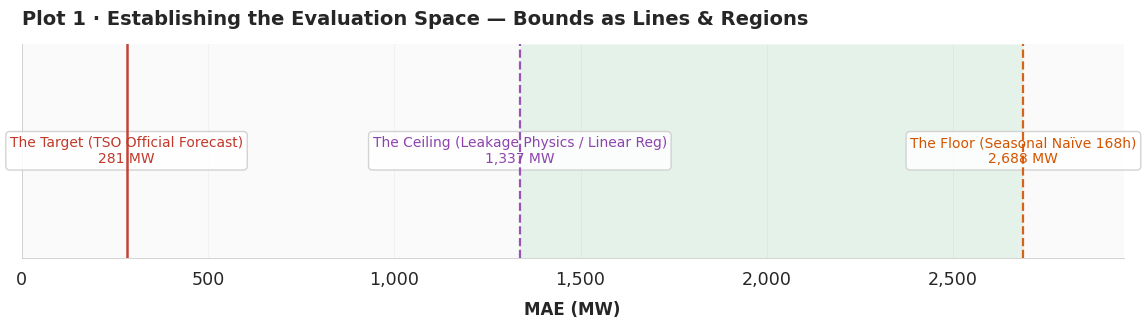


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 2 · The Pure Signal (Univariate h=24)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


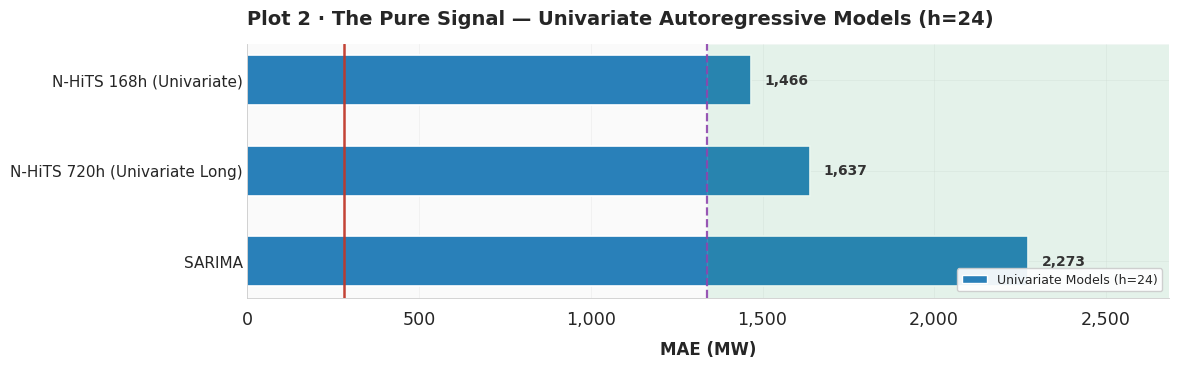


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 3 · Day-Ahead Multivariate Battle (h=24)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


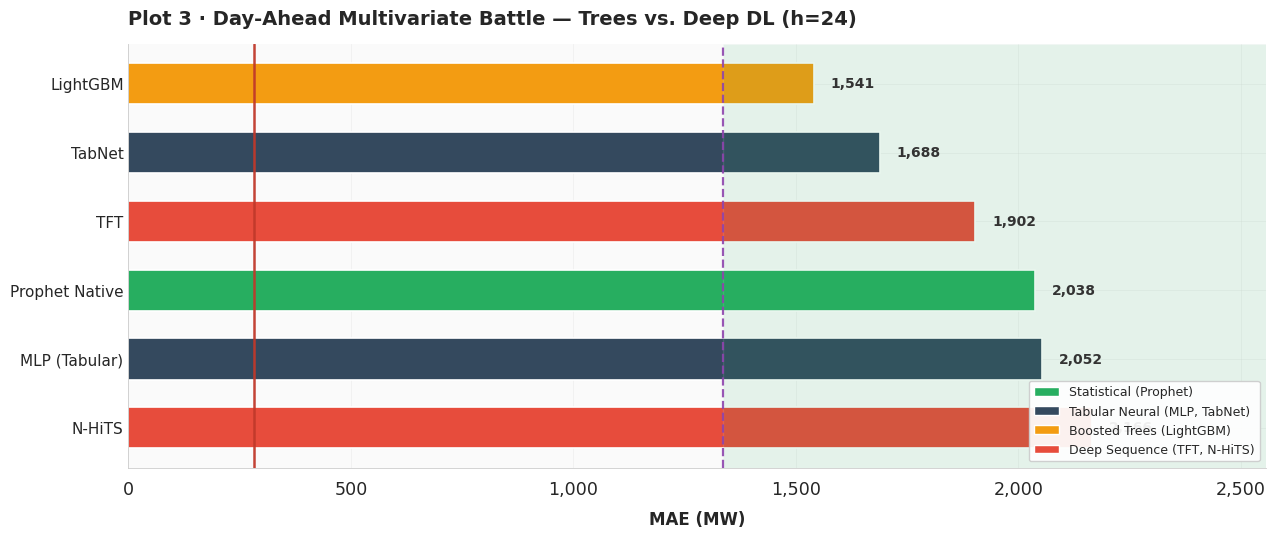


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 4 · The Sandbox (Modeling an Edge)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


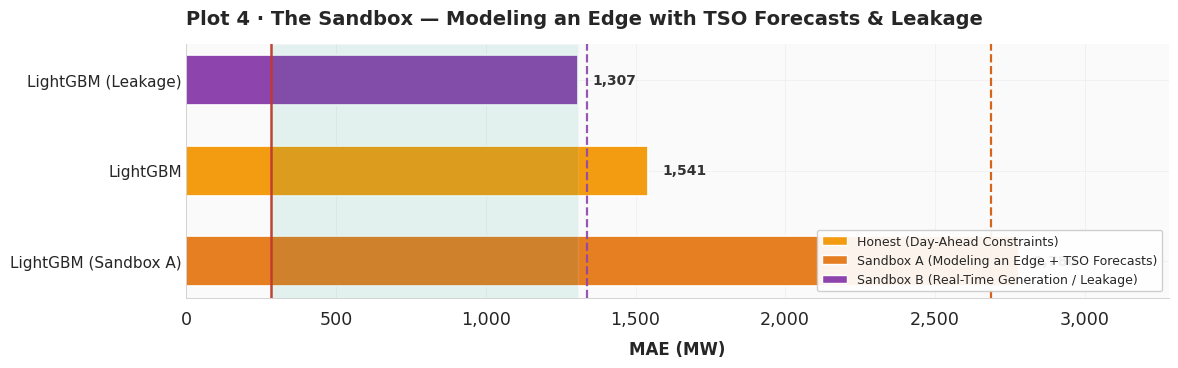


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 5 · The Intraday Arena (h=1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


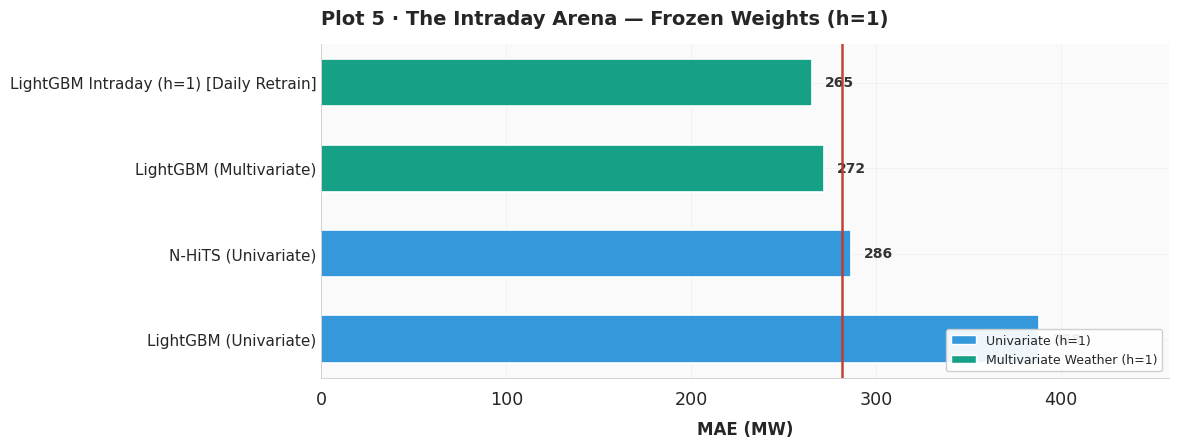


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 6 · The Horizon Paradigm Flip (h=24 vs h=1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


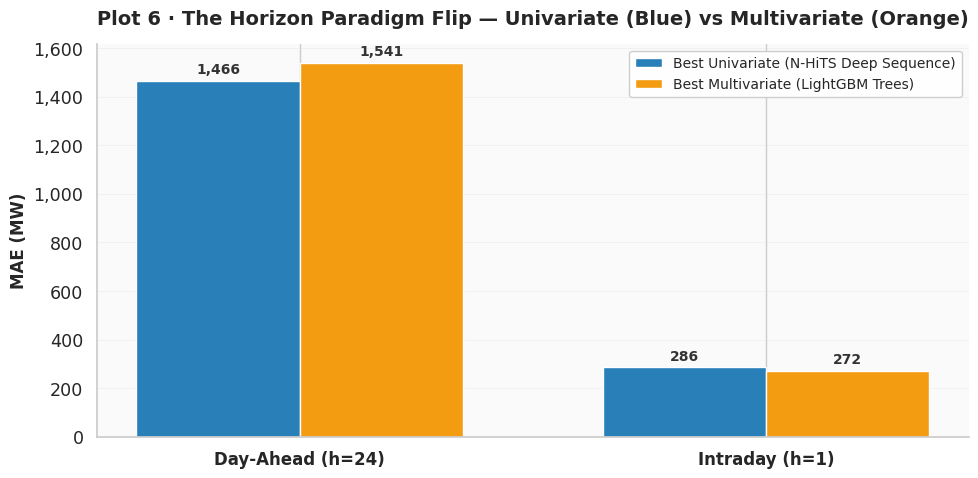


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Plot 7 · The Grand Finale (The Evolutionary Staircase)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


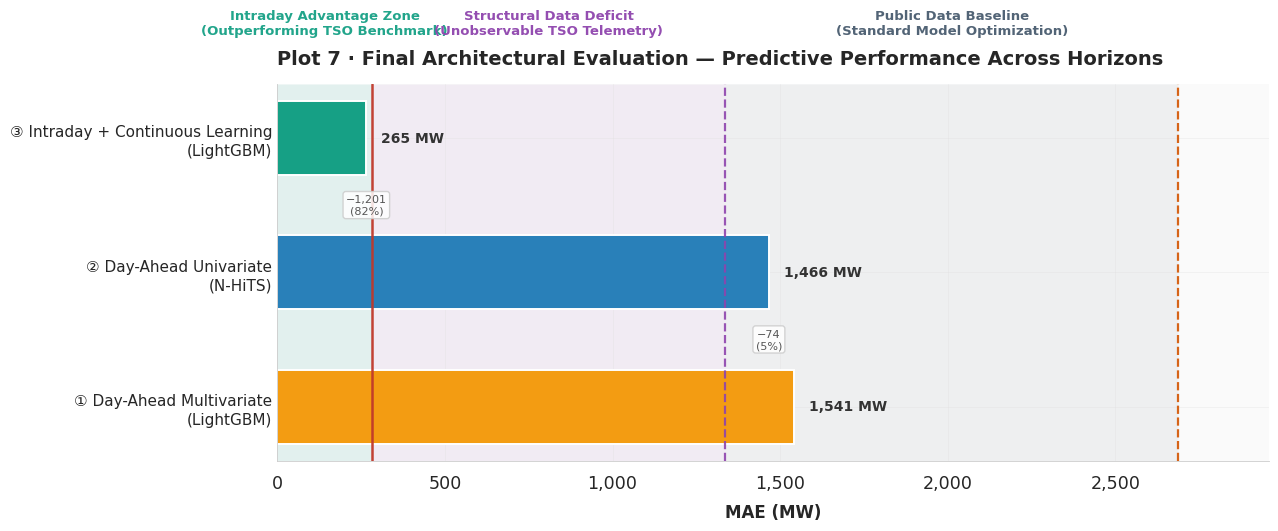

In [21]:
# ═══════════════════════════════════════════════════════════
# NARRATIVE VISUALISATION SUITE (5 Sequential Plots)
# ═══════════════════════════════════════════════════════════
from src.visualization.visualize_narrative import generate_narrative_plots

generate_narrative_plots(evaluator.results_list)